# Linear regression using the Scikit-Learn for single variable

In [12]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [10]:
iris=load_iris()
col_names=iris.feature_names
t_name=iris.target_names
df=pd.DataFrame(data=iris.data,columns=col_names)

<Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>

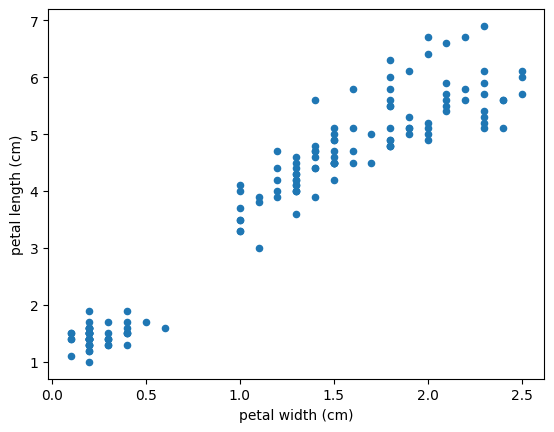

In [18]:
#EDA
df.plot.scatter(x='petal width (cm)', y='petal length (cm)')

#above or below both way we can print the graph

# plt.scatter(x=df['petal width (cm)'], y=df['petal length (cm)'])
# plt.show()

In [81]:
# pre processing
y=df['petal width (cm)'].values.reshape(-1,1)
x=df['petal length (cm)'].values.reshape(-1,1)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [77]:
# train the model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

print(regressor.intercept_)
print(regressor.coef_)

-0.3619366304897418
[0.41437875]


In [78]:
#prediction
score=regressor.predict([[7.5]])    #y=coef_*value + intercept_
print(score)

[2.74590398]


In [79]:
y_pred=regressor.predict(x_test)
df_pred=pd.DataFrame({'Actual':y_test.squeeze(), 'Predicted':y_pred.squeeze()})
print(df_pred)

    Actual  Predicted
0      1.6   2.041460
1      0.2   0.259631
2      2.3   2.082898
3      0.3   0.218194
4      1.5   1.668519
5      0.1   0.218194
6      0.2   0.176756
7      2.1   1.958584
8      1.1   1.254140
9      1.7   1.502768
10     0.2   0.218194
11     0.2   0.259631
12     1.1   1.212703
13     1.0   1.295578
14     1.5   1.502768
15     0.2   0.135318
16     1.3   1.295578
17     2.4   1.958584
18     0.3   0.218194
19     1.8   1.917146
20     2.3   2.165774
21     2.5   2.165774
22     1.3   1.337016
23     0.3   0.218194
24     1.3   1.544206
25     1.3   1.337016
26     0.5   0.342507
27     0.4   0.176756
28     2.3   1.751395
29     1.2   1.461330


In [80]:
#evaluating the model
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)

print(mae)
print(mse)
print(rmse)

0.16200868318663986
0.04479869674374007
0.21165702620924273


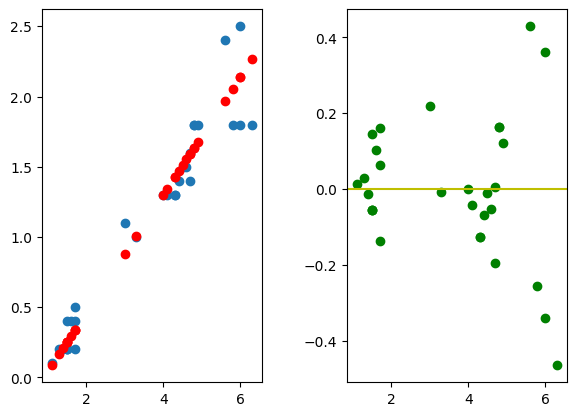

In [70]:
plt.subplot(1,2,1)
plt.scatter(x=x_test,y=y_test)
plt.scatter(x=x_test,y=y_pred,c='r')

plt.subplot(1,2,2)
plt.scatter(x=x_test,y=y_test-y_pred,c='g')
plt.axhline(y=0,c='y')

plt.tight_layout(pad=3.0)

plt.show()